In [12]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor

import mlflow
import dagshub
import mlflow.sklearn



In [13]:
# MLflow
dagshub.init(
    repo_owner='IzaKakhniashvili',
    repo_name='ML-assignment1-HousePrices',
    mlflow=True
)


Initialized MLflow to track repo "IzaKakhniashvili/ML-assignment1-HousePrices"

Repository IzaKakhniashvili/ML-assignment1-HousePrices initialized!

In [14]:
train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")

In [15]:
train.shape, test.shape

((1460, 81), (1459, 80))

In [16]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [17]:
train["SalePrice"].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

In [18]:
train.isnull().sum().sort_values(ascending=False).head(20)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageYrBlt       81
GarageCond        81
GarageType        81
GarageFinish      81
GarageQual        81
BsmtFinType2      38
BsmtExposure      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
Id                 0
dtype: int64

/var/folders/fv/v82rbzd93zncm130fndf1ryc0000gn/T/ipykernel_9213/3543292081.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


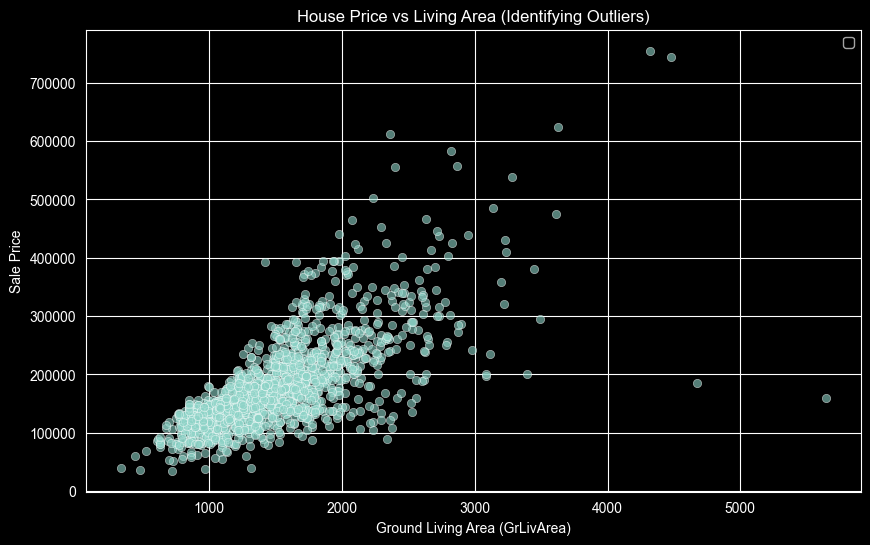

In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.scatterplot(data=train, x='GrLivArea', y='SalePrice', alpha=0.6)

plt.title('House Price vs Living Area (Identifying Outliers)')
plt.xlabel('Ground Living Area (GrLivArea)')
plt.ylabel('Sale Price')
plt.legend()
plt.show()

## Baseline

In [20]:
y = train["SalePrice"]
X = train.drop("SalePrice", axis=1)


In [21]:
# mode/median ით დავჰენდლეთ ყველაზე მარტივად
for col in X.columns:
    if X[col].dtype == "object":
        X[col] = X[col].fillna(X[col].mode()[0])
    else:
        X[col] = X[col].fillna(X[col].median())

In [22]:
X = pd.get_dummies(X)
X

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,...,False,False,False,True,False,False,False,False,True,False
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,...,False,False,False,True,False,False,False,False,True,False
2,3,60,68.0,11250,7,5,2001,2002,162.0,486,...,False,False,False,True,False,False,False,False,True,False
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,...,False,False,False,True,True,False,False,False,False,False
4,5,60,84.0,14260,8,5,2000,2000,350.0,655,...,False,False,False,True,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,62.0,7917,6,5,1999,2000,0.0,0,...,False,False,False,True,False,False,False,False,True,False
1456,1457,20,85.0,13175,6,6,1978,1988,119.0,790,...,False,False,False,True,False,False,False,False,True,False
1457,1458,70,66.0,9042,7,9,1941,2006,0.0,275,...,False,False,False,True,False,False,False,False,True,False
1458,1459,20,68.0,9717,5,6,1950,1996,0.0,49,...,False,False,False,True,False,False,False,False,True,False


In [23]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [24]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [36]:
from sklearn.metrics import mean_squared_log_error

preds = model.predict(X_val)
rmsle = np.sqrt(mean_squared_log_error(y_val, preds))

rmsle

np.float64(0.18870166575511044)

In [26]:
r2 = r2_score(y_val, preds)
r2

0.886092484333137

In [27]:
mae = mean_absolute_error(y_val, preds)
mae

18262.222434916726

In [37]:
import mlflow

with mlflow.start_run():
    mlflow.log_param("model", "LinearRegression")
    mlflow.log_param("stage", "baseline")

    mlflow.log_metric("rmsle", rmsle)
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("r2", r2)

    mlflow.sklearn.log_model(
        model,
        "model",
        registered_model_name="house_price_model"
    )

2026/04/15 21:07:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/15 21:07:27 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'house_price_model' already exists. Creating a new version of this model...
2026/04/15 21:07:35 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: house_price_model, version 19
Created version '19' of model 'house_price_model'.


🏃 View run delicate-carp-725 at: https://dagshub.com/IzaKakhniashvili/ML-assignment1-HousePrices.mlflow/#/experiments/0/runs/dae9f694287d4256a716c11442a8e946
🧪 View experiment at: https://dagshub.com/IzaKakhniashvili/ML-assignment1-HousePrices.mlflow/#/experiments/0


## Ex1_Categorial Expansion and Correlation

### Data Cleaning

In [40]:
X = train.drop("SalePrice", axis=1)
y = train["SalePrice"]
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [41]:
X_tr = X_train.copy()
X_v = X_val.copy()

In [42]:
num_cols = X_tr.select_dtypes(include=[np.number]).columns
X_tr[num_cols] = X_tr[num_cols].fillna(X_tr[num_cols].median())
X_v[num_cols] = X_v[num_cols].fillna(X_tr[num_cols].median())

In [43]:
cat_cols = X_tr.select_dtypes(include=['object']).columns
X_tr[cat_cols] = X_tr[cat_cols].fillna("None")
X_v[cat_cols] = X_v[cat_cols].fillna("None")

### Feature Engineering

In [44]:
for df in [X_tr, X_v]:
    df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
    df['HouseAge'] = df['YrSold'] - df['YearBuilt']

df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,TotalSF,HouseAge
892,893,20,RL,70.0,8414,Pave,None,Reg,Lvl,AllPub,...,None,MnPrv,None,0,2,2006,WD,Normal,2127,43
1105,1106,60,RL,98.0,12256,Pave,None,IR1,Lvl,AllPub,...,None,None,None,0,4,2010,WD,Normal,4085,16
413,414,30,RM,56.0,8960,Pave,Grvl,Reg,Lvl,AllPub,...,None,None,None,0,3,2010,WD,Normal,2036,83
522,523,50,RM,50.0,5000,Pave,None,Reg,Lvl,AllPub,...,None,None,None,0,10,2006,WD,Normal,2668,59
1036,1037,20,RL,89.0,12898,Pave,None,IR1,HLS,AllPub,...,None,None,None,0,9,2009,WD,Normal,3240,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
479,480,30,RM,50.0,5925,Pave,None,Reg,Bnk,AllPub,...,None,MnPrv,None,0,3,2007,WD,Alloca,2038,70
1361,1362,20,RL,124.0,16158,Pave,None,IR1,Low,AllPub,...,None,None,None,0,6,2009,WD,Normal,3060,4
802,803,60,RL,63.0,8199,Pave,None,Reg,Lvl,AllPub,...,None,None,None,0,10,2008,WD,Normal,2184,3
651,652,70,RL,60.0,9084,Pave,None,Reg,Lvl,AllPub,...,None,MnPrv,None,0,10,2009,WD,Normal,2265,69


In [45]:
X_tr['is_train'] = 1
X_v['is_train'] = 0
combined = pd.concat([X_tr, X_v])

combined_encoded = pd.get_dummies(combined, columns=cat_cols)

X_tr_enc = combined_encoded[combined_encoded['is_train'] == 1].drop('is_train', axis=1)
X_v_enc = combined_encoded[combined_encoded['is_train'] == 0].drop('is_train', axis=1)

### Feature Selection

In [46]:
temp_df = pd.concat([X_tr_enc, y_train], axis=1)
corr_matrix = temp_df.corr()

threshold = 0.4
relevant_cols = corr_matrix['SalePrice'][abs(corr_matrix['SalePrice']) > threshold].index.tolist()
relevant_cols


['OverallQual',
 'YearBuilt',
 'YearRemodAdd',
 'MasVnrArea',
 'TotalBsmtSF',
 '1stFlrSF',
 'GrLivArea',
 'FullBath',
 'TotRmsAbvGrd',
 'Fireplaces',
 'GarageYrBlt',
 'GarageCars',
 'GarageArea',
 'TotalSF',
 'HouseAge',
 'ExterQual_Ex',
 'ExterQual_Gd',
 'ExterQual_TA',
 'Foundation_PConc',
 'BsmtQual_Ex',
 'BsmtQual_TA',
 'BsmtFinType1_GLQ',
 'HeatingQC_Ex',
 'KitchenQual_Ex',
 'KitchenQual_TA',
 'FireplaceQu_None',
 'GarageFinish_Fin',
 'GarageFinish_Unf',
 'SalePrice']

In [47]:
relevant_cols.remove('SalePrice')

X_tr_final = X_tr_enc[relevant_cols]
X_v_final = X_v_enc[relevant_cols]

In [48]:
model_a = LinearRegression()
model_a.fit(X_tr_final, y_train)
preds = model_a.predict(X_v_final)

In [49]:
rmsle = np.sqrt(mean_squared_log_error(y_val, preds))

rmsle

np.float64(0.17298196196950952)

In [50]:
r2 = r2_score(y_val, preds)
r2

0.8424206763480444

In [51]:
mae = mean_absolute_error(y_val, preds)
mae

22149.141288559178

In [52]:
with mlflow.start_run(run_name="Exp_A"):
    mlflow.log_param("model", "LinearRegression")
    mlflow.log_param("stage", "Experiment A")
    mlflow.log_param("corr_threshold", threshold)
    mlflow.log_param("final_features", len(relevant_cols))
    mlflow.log_metric("rmse", rmsle)
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("r2", r2)

    mlflow.sklearn.log_model(
        model,
        "model",
        registered_model_name="house_price_model"
    )

2026/04/15 21:08:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/15 21:08:28 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'house_price_model' already exists. Creating a new version of this model...
2026/04/15 21:08:37 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: house_price_model, version 20
Created version '20' of model 'house_price_model'.


🏃 View run Exp_A at: https://dagshub.com/IzaKakhniashvili/ML-assignment1-HousePrices.mlflow/#/experiments/0/runs/8ee9befd585342cf8b9a6a4946d35407
🧪 View experiment at: https://dagshub.com/IzaKakhniashvili/ML-assignment1-HousePrices.mlflow/#/experiments/0


## Ex2_Added Log Transformation

### Data Cleaning

In [53]:
X = train.drop("SalePrice", axis=1)
y = train["SalePrice"]
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [54]:
X_tr = X_train.copy()
X_v = X_val.copy()

In [55]:
num_cols = X_tr.select_dtypes(include=[np.number]).columns
cat_cols = X_tr.select_dtypes(include=['object']).columns

X_tr[num_cols] = X_tr[num_cols].fillna(X_tr[num_cols].median())
X_v[num_cols] = X_v[num_cols].fillna(X_tr[num_cols].median())

X_tr[cat_cols] = X_tr[cat_cols].fillna("None")
X_v[cat_cols] = X_v[cat_cols].fillna("None")

### Feature Engineering

In [56]:
for df in [X_tr, X_v]:
    df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
    df['TotalBath'] = df['FullBath'] + (0.5 * df['HalfBath']) + df['BsmtFullBath'] + (0.5 * df['BsmtHalfBath'])
    df['HouseAge'] = df['YrSold'] - df['YearBuilt']
    df.fillna(0, inplace=True)

In [57]:
X_tr['is_train'] = 1
X_v['is_train'] = 0
combined = pd.concat([X_tr, X_v])
combined_encoded = pd.get_dummies(combined, columns=cat_cols)

X_tr_enc = combined_encoded[combined_encoded['is_train'] == 1].drop('is_train', axis=1)
X_v_enc = combined_encoded[combined_encoded['is_train'] == 0].drop('is_train', axis=1)

In [58]:
y_train_log = np.log1p(y_train)

### Feature Selection

In [59]:
temp_df = pd.concat([X_tr_enc, y_train], axis=1)
corr_matrix = temp_df.corr()
threshold = 0.2
relevant_cols = corr_matrix['SalePrice'][abs(corr_matrix['SalePrice']) > threshold].index.tolist()
if 'SalePrice' in relevant_cols: relevant_cols.remove('SalePrice')
relevant_cols

['LotFrontage',
 'LotArea',
 'OverallQual',
 'YearBuilt',
 'YearRemodAdd',
 'MasVnrArea',
 'BsmtFinSF1',
 'BsmtUnfSF',
 'TotalBsmtSF',
 '1stFlrSF',
 '2ndFlrSF',
 'GrLivArea',
 'BsmtFullBath',
 'FullBath',
 'HalfBath',
 'TotRmsAbvGrd',
 'Fireplaces',
 'GarageYrBlt',
 'GarageCars',
 'GarageArea',
 'WoodDeckSF',
 'OpenPorchSF',
 'TotalSF',
 'TotalBath',
 'HouseAge',
 'MSZoning_RL',
 'MSZoning_RM',
 'LotShape_Reg',
 'Neighborhood_NoRidge',
 'Neighborhood_NridgHt',
 'Neighborhood_StoneBr',
 'HouseStyle_2Story',
 'RoofStyle_Gable',
 'RoofStyle_Hip',
 'Exterior1st_VinylSd',
 'Exterior2nd_VinylSd',
 'MasVnrType_None',
 'MasVnrType_Stone',
 'ExterQual_Ex',
 'ExterQual_Gd',
 'ExterQual_TA',
 'Foundation_CBlock',
 'Foundation_PConc',
 'BsmtQual_Ex',
 'BsmtQual_Gd',
 'BsmtQual_TA',
 'BsmtExposure_Gd',
 'BsmtExposure_No',
 'BsmtFinType1_GLQ',
 'HeatingQC_Ex',
 'HeatingQC_TA',
 'CentralAir_N',
 'CentralAir_Y',
 'Electrical_SBrkr',
 'KitchenQual_Ex',
 'KitchenQual_Gd',
 'KitchenQual_TA',
 'FireplaceQ

In [60]:
X_tr_final = X_tr_enc[relevant_cols]
X_v_final = X_v_enc[relevant_cols]

In [61]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_tr_scaled = scaler.fit_transform(X_tr_final)
X_v_scaled = scaler.transform(X_v_final)

In [62]:
model = LinearRegression()
model.fit(X_tr_scaled, y_train_log)

log_preds = model.predict(X_v_scaled)
final_preds = np.expm1(log_preds)

In [63]:
rmsle = np.sqrt(mean_squared_log_error(y_val, final_preds))
rmsle

np.float64(0.15381023830399207)

In [64]:
r2 = r2_score(y_val, preds)
r2

0.8424206763480444

In [65]:
mae = mean_absolute_error(y_val, preds)
mae

22149.141288559178

In [66]:
with mlflow.start_run(run_name="Exp_B"):
    mlflow.log_param("model", "LinearRegression")
    mlflow.log_param("stage", "Experiment B")
    mlflow.log_param("corr_threshold", threshold)
    mlflow.log_param("final_features", len(relevant_cols))
    mlflow.log_metric("rmse", rmsle)
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("r2", r2)

    mlflow.sklearn.log_model(
        model,
        "model",
        registered_model_name="house_price_model"
    )

2026/04/15 21:09:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/15 21:09:45 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'house_price_model' already exists. Creating a new version of this model...
2026/04/15 21:09:54 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: house_price_model, version 21
Created version '21' of model 'house_price_model'.


🏃 View run Exp_B at: https://dagshub.com/IzaKakhniashvili/ML-assignment1-HousePrices.mlflow/#/experiments/0/runs/1888affa8341448a9faee334330e8d6a
🧪 View experiment at: https://dagshub.com/IzaKakhniashvili/ML-assignment1-HousePrices.mlflow/#/experiments/0
